## Imports & Connection

In [1]:
import os
import re
import time

import numpy as np
import pandas as pd
import hiplot as hip
import matplotlib.pyplot as plt
import datetime as datetime

from scipy import stats
from pyhive import presto
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
os.environ['PYDEVD_DISABLE_FILE_VALIDATION'] = '1'

In [2]:
## Connection
connection = presto.connect(
        host='presto-gateway.serving.data.production.internal',
        port=80,
        protocol='http',
        catalog='hive',
        username='manoj.ravirajan@rapido.bike'
)

In [3]:
# Get the current working directory
cwd = os.getcwd()
print(cwd)
local_datasets = '/Users/rapido/local-datasets/customer/appography/appography_v2/bangalore/'
print(local_datasets)

data_dumper_path = '/Users/rapido/local-datasets/customer/appography/appography_data_dump/'

/Users/rapido/analytics/customer/Appography/Appography_v2
/Users/rapido/local-datasets/customer/appography/appography_v2/bangalore/


## Parameter & Datasets

In [4]:
start_date = '20240301' 
end_date = '20240331'
city = 'Bangalore'

In [5]:
df_base_customers_app_data = pd.read_csv(local_datasets + '{}_city_fe_customer_with_appo_data.csv'.format(city))

In [6]:
df_base_customers_app_data['city'] = city

In [7]:
print('Users without age values' ,(df_base_customers_app_data[df_base_customers_app_data['age'].isna()]['user_id'].nunique()*100.00/df_base_customers_app_data['user_id'].nunique()))
print('Users with age values' ,(df_base_customers_app_data[~df_base_customers_app_data['age'].isna()]['user_id'].nunique()*100.00/df_base_customers_app_data['user_id'].nunique()))

Users without age values 66.88718702109409
Users with age values 33.11281297890591


### Mobile app to category mapping

In [8]:
category_list = pd.read_csv('/Users/rapido/local-datasets/customer/appography/appography_v1/category_list_v1.csv')
category_list['app_name'] = category_list['app_name'].str.lower()
category_list['categories_l1'] = category_list['categories_l1'].str.lower()
category_list['categories_l2'] = category_list['categories_l2'].str.lower()
category_list = category_list[['app_name', 'categories_l1', 'categories_l2']]
print(category_list.shape)
print(category_list.categories_l1.unique())
print(category_list.categories_l2.unique())
category_list.head(1)

(399, 3)
['educational' 'ott' 'delivery_grocery' 'tools' 'office' 'dating' 'news'
 'devotional' 'travel_metro' 'gaming' 'travel_bookings'
 'finance_transactions' 'ecommerce' 'streaming_music' 'finance_investment'
 'health' 'fantasy_sports' 'delivery_food' 'home_security' 'finance_news'
 'travel_ridehailing' 'social' 'telecom' 'entertainment' 'news_finance'
 'wearable' 'driver_app']
['educational' 'rest' 'office' 'ride haling' 'gaming' 'finance_investment'
 'driver_app']


,app_name,categories_l1,categories_l2
0,ignou e-content,educational,educational


core_education = ['aakash','chegg study','google classroom','microsoft math solver','simplilearn','moodle','vedantu','vidyakul','diksha','e-pg pathshala','mycbseguide','physics wallah']
core_office = ['slack','asana','confluence','jira','cisco','github','google analytics','miro','trello','zoho mail','zoho meeting']
core_social = ['hike','facebook','messenger','instagram','linkedin','moj','pinterest','skype','snapchat','twitter','whatsapp','tiktok','josh','sharechat']

category_list['categories_l3'] = np.where(category_list['app_name'].isin(core_education), 'core_education',  #category_list['app_name'],
                                 np.where(category_list['app_name'].isin(core_office), 'core_office', #category_list['app_name'],
                                 np.where(category_list['app_name'].isin(core_social), 'core_social',
                                 np.where(category_list['app_name'].isin(['intune  company portal']), 'intune  company portal',         
                                 category_list['categories_l1']))))

In [9]:
core_education = ['aakash','chegg study','google classroom','microsoft math solver',
                  'simplilearn','moodle','vedantu','vidyakul','diksha',
                  'e-pg pathshala','mycbseguide','physics wallah']
core_office = ['slack','asana','confluence','jira','cisco','github',
               'google analytics','miro','trello','zoho mail','zoho meeting']
top_categories = ['dating', 'delivery_food', 'driver_app', 'entertainment', 
                  'finance_investment', 'gaming', 'office', 'social', 
                  'streaming_music', 'travel_bookings', 'travel_ridehailing']


category_list['top_categories'] = np.where(category_list['app_name'].isin(core_education), 'core_education',  #category_list['app_name'],
                                 np.where(category_list['app_name'].isin(core_office), 'core_office', #category_list['app_name'],
                                 np.where(category_list['categories_l1'].isin(top_categories), category_list['categories_l1'],
                                         'rest'
                                         )))

In [10]:
category_list.head(4)

,app_name,categories_l1,categories_l2,top_categories
0,ignou e-content,educational,educational,rest
1,aha,ott,rest,rest
2,grofers delivery app,delivery_grocery,rest,rest
3,qr code reader,tools,rest,rest


## Explode mobile app's and mapping categories 

In [11]:
df_customers_with_appography = df_base_customers_app_data[~df_base_customers_app_data['age'].isna()]
df_customers_with_appography.head(4)

,user_id,age,gender,customer_id,app_list_set,city
2,6466641674d89382040f2c87,26.0,MALE,6466641674d89382040f2c87,"['booking.com', 'google slides', 'cred', 'micr...",Bangalore
4,5c7d28ba875c98536260f476,28.0,FEMALE,5c7d28ba875c98536260f476,"['meesho', 'paytm money', 'namma yatri', 'uber...",Bangalore
6,5e675f15b9fe96fa9379cdac,26.0,FEMALE,5e675f15b9fe96fa9379cdac,"['webex', 'namma yatri', 'meesho', 'youtube', ...",Bangalore
8,6019087c73262d088dc9b5d0,27.0,FEMALE,6019087c73262d088dc9b5d0,"['netflix', 'gmail', 'namma yatri', 'voot', 'i...",Bangalore


In [12]:
def extract_and_trim(text):
    return [val.strip() for val in re.findall(r"'([^']*)'", text)]

df_customers_with_appography['app_list_set'] = df_customers_with_appography['app_list_set'].apply(lambda x: extract_and_trim(x))
df_customers_with_appography = df_customers_with_appography[['city', 'user_id', 'age', 'gender', 
#                                                              'first_half_drop_primary', 'first_half_drop_secondary',
#                                                              'second_half_pickup_primary','second_half_pickup_secondary',
                                                             'app_list_set']]
df_customers_with_appography.head(4)

,city,user_id,age,gender,app_list_set
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,"[booking.com, google slides, cred, microsoft t..."
4,Bangalore,5c7d28ba875c98536260f476,28.0,FEMALE,"[meesho, paytm money, namma yatri, uber, nykaa..."
6,Bangalore,5e675f15b9fe96fa9379cdac,26.0,FEMALE,"[webex, namma yatri, meesho, youtube, whatsapp..."
8,Bangalore,6019087c73262d088dc9b5d0,27.0,FEMALE,"[netflix, gmail, namma yatri, voot, instagram,..."


In [13]:
## Explode list into individual rows

df_customers_with_appography_explode = df_customers_with_appography.explode('app_list_set')
df_customers_with_appography_explode['app_list_set'] = df_customers_with_appography_explode['app_list_set'].str.lower()

df_customers_with_appography_explode.head(4)

,city,user_id,age,gender,app_list_set
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,booking.com
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,google slides
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,cred
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,microsoft teams


### Filtering top categories apps

In [14]:
top_apps_list = category_list[category_list['top_categories'] != 'rest']['app_name'].values.tolist()
top_apps_list

['nishtha',
 'hinge',
 'wunderlist',
 'slack',
 'afterlight',
 'airbnb',
 'aisle',
 'amazon music',
 'angel broking',
 'apple music',
 'zomato',
 'asana',
 'confluence',
 'jira',
 'trello',
 'ms authenticator',
 'blusmart',
 'booking.com',
 'hike',
 'wynk music',
 'bookmyshow',
 'bumble',
 'aakash',
 'chegg study',
 'chingari',
 'cisco',
 'webex',
 'cleartrip',
 'coffee meets bagel',
 'quick ride',
 'quickride',
 "domino's pizza",
 'driveu driver app',
 'dropbox',
 'free fire',
 'dunzo',
 'expedia',
 'facebook',
 'messenger',
 'foodpanda',
 'happn',
 'gaana',
 'github',
 'goibibo',
 'google authenticator',
 'google classroom',
 'google analytics',
 'hdfc securities',
 'hungama music',
 'icici direct',
 'instagram',
 'mx takatak',
 'jiosaavn',
 'kayak',
 'kfc india',
 'kotak stock trader',
 'linkedin',
 'ludo king',
 'dubsmash',
 'makemytrip',
 "mcdonald's india",
 'bolo indya',
 'microsoft kaizala',
 'microsoft math solver',
 'microsoft office suite',
 'microsoft 365',
 'outlook',
 'on

In [15]:
df_customers_main_apps_explode = df_customers_with_appography_explode[df_customers_with_appography_explode['app_list_set'].isin(top_apps_list)]

### Merge

In [16]:
df_customers_main_apps_explode.head(2)

,city,user_id,age,gender,app_list_set
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,booking.com
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,microsoft teams


In [17]:
category_list.head(2)

,app_name,categories_l1,categories_l2,top_categories
0,ignou e-content,educational,educational,rest
1,aha,ott,rest,rest


dating<br>
delivery_food<br>
driver_app<br>
core_education<br>
entertainment<br>
finance_investment<br>
gaming<br>
core_office<br>
office<br>
social<br>
streaming_music<br>
travel_bookings<br>
travel_ridehailing<br>

In [18]:
df_customers_main_app_category =  pd.merge(df_customers_main_apps_explode,
                                           category_list, 
                                           how='left', 
                                           left_on='app_list_set',  
                                           right_on='app_name'
                                          )
df_customers_main_app_category.head(4)

,city,user_id,age,gender,app_list_set,app_name,categories_l1,categories_l2,top_categories
0,Bangalore,6466641674d89382040f2c87,26.0,MALE,booking.com,booking.com,travel_bookings,rest,travel_bookings
1,Bangalore,6466641674d89382040f2c87,26.0,MALE,microsoft teams,microsoft teams,office,office,office
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,linkedin,linkedin,social,rest,social
3,Bangalore,6466641674d89382040f2c87,26.0,MALE,whatsapp,whatsapp,social,rest,social


#### Distribution check on categories

In [19]:
total_customers = df_customers_main_app_category.user_id.nunique()
total_customers

647611

In [20]:
df_temp = df_customers_main_app_category\
            .groupby(['categories_l1'])\
            .agg(app_list = ('app_list_set', lambda x: list(set(x))),
                 customers = ('user_id','nunique'))\
            .sort_values(['customers'],ascending=False)\
            .reset_index()
df_temp['%'] =  (df_temp['customers']*100.00/total_customers).round(2)
df_temp

,categories_l1,app_list,customers,%
0,social,"[linkedin, instagram, skype, mx takatak, wecha...",647012,99.91
1,travel_ridehailing,"[quick ride, blusmart, jugnoo, ola, uber, namm...",499397,77.11
2,delivery_food,"[zomato, dunzo, swiggy, uber eats]",454635,70.20
3,streaming_music,"[soundcloud, wynk music, hungama music, gaana,...",445790,68.84
4,office,"[slack, jira, zoho meeting, ms authenticator, ...",406087,62.71
5,finance_investment,"[hdfc mobile banking, nps, kite by zerodha, gr...",297696,45.97
6,entertainment,[bookmyshow],253991,39.22
7,travel_bookings,"[indigo, kayak, cleartrip, goibibo, yatra, tri...",232135,35.84
8,driver_app,"[zomato driver app, swiggy driver app, dunzo d...",120653,18.63
9,gaming,[ludo king],93745,14.48


In [21]:
df_temp = df_customers_main_app_category\
            .groupby(['categories_l2'])\
            .agg(app_list = ('app_list_set', lambda x: list(set(x))),
                 customers = ('user_id','nunique'))\
            .sort_values(['customers'],ascending=False)\
            .reset_index()
df_temp['%'] =  (df_temp['customers']*100.00/total_customers).round(2)
df_temp

,categories_l2,app_list,customers,%
0,rest,"[indigo, tripadvisor, goibibo, mx takatak, bum...",647382,99.96
1,ride haling,"[quick ride, blusmart, jugnoo, ola, uber, namm...",499397,77.11
2,office,"[slack, jira, zoho meeting, ms authenticator, ...",406087,62.71
3,finance_investment,"[hdfc mobile banking, nps, kite by zerodha, gr...",297696,45.97
4,driver_app,"[zomato driver app, swiggy driver app, dunzo d...",120653,18.63
5,gaming,[ludo king],93745,14.48
6,educational,"[diksha, physics wallah, vedantu, vidyakul, si...",39906,6.16


In [22]:
df_temp = df_customers_main_app_category[~df_customers_main_app_category['categories_l2'].isin(['rest'])]\
            .groupby(['categories_l2','app_list_set'])\
            .agg(customers = ('user_id','nunique'))\
            .sort_values(by=['categories_l2', 'customers'], ascending=[False, False])\
            .reset_index()
df_temp['%'] =  (df_temp['customers']*100.00/total_customers).round(2)
df_temp

,categories_l2,app_list_set,customers,%
0,ride haling,ola,399708,61.72
1,ride haling,uber,354065,54.67
2,ride haling,namma yatri,143646,22.18
3,ride haling,quick ride,23449,3.62
4,ride haling,in drive,22155,3.42
5,ride haling,blusmart,20642,3.19
6,ride haling,driveu driver app,4163,0.64
7,ride haling,quickride,1694,0.26
8,ride haling,jugnoo,899,0.14
9,office,outlook,179867,27.77


## Transform Categories 

In [23]:
df_customers_main_app_category.head(4)

,city,user_id,age,gender,app_list_set,app_name,categories_l1,categories_l2,top_categories
0,Bangalore,6466641674d89382040f2c87,26.0,MALE,booking.com,booking.com,travel_bookings,rest,travel_bookings
1,Bangalore,6466641674d89382040f2c87,26.0,MALE,microsoft teams,microsoft teams,office,office,office
2,Bangalore,6466641674d89382040f2c87,26.0,MALE,linkedin,linkedin,social,rest,social
3,Bangalore,6466641674d89382040f2c87,26.0,MALE,whatsapp,whatsapp,social,rest,social


In [24]:
df_customer_mapped = df_customers_main_app_category\
                        .groupby(['city', 'user_id', 'age'
#                                   ,'first_half_drop_primary', 'first_half_drop_secondary',
#                                   'second_half_pickup_primary','second_half_pickup_secondary'
                                 ])\
                        .agg(
                             app_list = ('app_list_set', lambda x: list(set(x))),
                             top_categories = ('top_categories', lambda x: list(set(x)))
                            )\
                        .reset_index()

df_customer_mapped.head(4)

,city,user_id,age,app_list,top_categories
0,Bangalore,5737c6aeddbec2203f733176,34.0,"[outlook, instagram, dunzo, zomato, onedrive, ...","[finance_investment, delivery_food, social, of..."
1,Bangalore,5737c6b0ddbec2203f733182,28.0,"[bookmyshow, instagram, dunzo, mx takatak, zom...","[entertainment, driver_app, delivery_food, str..."
2,Bangalore,5737c6b1ddbec2203f73318b,33.0,"[instagram, dunzo, goibibo, zomato, zoom, twit...","[driver_app, delivery_food, social, office, tr..."
3,Bangalore,5737c6c5ddbec2203f733239,28.0,"[instagram, hdfc mobile banking, wynk music, r...","[social, finance_investment, streaming_music, ..."


In [25]:
unique_categories = set(category for sublist in df_customer_mapped['app_list'] for category in sublist)
unique_categories_list = list(unique_categories)
print("Count of unique apps:", len(unique_categories))
sorted(unique_categories)

Count of unique apps: 109


['aakash',
 'airbnb',
 'aisle',
 'amazon music',
 'angel broking',
 'asana',
 'blusmart',
 'booking.com',
 'bookmyshow',
 'borzo driver app',
 'bumble',
 'chegg study',
 'cisco',
 'cleartrip',
 'coffee meets bagel',
 'confluence',
 'diksha',
 'driveu driver app',
 'dropbox',
 'dunzo',
 'dunzo driver app',
 'e-pg pathshala',
 'facebook',
 'flipboard',
 'gaana',
 'github',
 'goibibo',
 'google analytics',
 'google authenticator',
 'google classroom',
 'groww',
 'happn',
 'hdfc mobile banking',
 'hike',
 'hinge',
 'hungama music',
 'in drive',
 'indigo',
 'instagram',
 'intune  company portal',
 'jira',
 'jugnoo',
 'kayak',
 'kite by zerodha',
 'line',
 'linkedin',
 'ludo king',
 'messenger',
 'microsoft 365',
 'microsoft math solver',
 'microsoft teams',
 'miro',
 'moodle',
 'ms authenticator',
 'mx takatak',
 'mycbseguide',
 'namma partner',
 'namma yatri',
 'nishtha',
 'nps',
 'okcupid',
 'ola',
 'ola driver app',
 'onedrive',
 'outlook',
 'physics wallah',
 'pinterest',
 'pocket',
 'p

In [26]:
for category in unique_categories:
    df_customer_mapped[category] = df_customer_mapped['app_list'].apply(lambda x: 1 if category in x else 0) 
    
df_customer_mapped.head(1)

,city,user_id,age,app_list,top_categories,diksha,jira,tripadvisor,mx takatak,goibibo,ms authenticator,zoho meeting,quackquack,swiggy,uber,nishtha,cisco,telegram,pocket,namma yatri,trello,microsoft teams,whatsapp,redbus,airbnb,kite by zerodha,hungama music,chegg study,borzo driver app,instagram,kayak,flipboard,intune company portal,mycbseguide,messenger,shadowfax driver app,aakash,swiggy driver app,indigo,bumble,sharechat,zepto driver app,rapido captain,onedrive,porter driver app,google authenticator,zomato driver app,zoom,trivago,wynk music,line,happn,spotify,zomato,uber eats,soundcloud,vedantu,gaana,angel broking,bookmyshow,roposo,hike,microsoft math solver,booking.com,hdfc mobile banking,viber,uber driver app,dropbox,in drive,tinder,outlook,zoho mail,twitter,amazon music,ola,facebook,asana,moodle,miro,blusmart,pinterest,dunzo driver app,e-pg pathshala,dunzo,microsoft 365,slack,webex,ludo king,simplilearn,okcupid,trulymadly,google classroom,aisle,google analytics,cleartrip,yatra,nps,quick ride,confluence,groww,snapchat,github,vidyakul,linkedin,coffee meets bagel,skype,hinge,ola driver app,jugnoo,driveu driver app,wechat,physics wallah,namma partner,quickride
0,Bangalore,5737c6aeddbec2203f733176,34.0,"[outlook, instagram, dunzo, zomato, onedrive, ...","[finance_investment, delivery_food, social, of...",0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
df_customer_mapped.columns

Index(['city', 'user_id', 'age', 'app_list', 'top_categories', 'diksha',
       'jira', 'tripadvisor', 'mx takatak', 'goibibo',
       ...
       'coffee meets bagel', 'skype', 'hinge', 'ola driver app', 'jugnoo',
       'driveu driver app', 'wechat', 'physics wallah', 'namma partner',
       'quickride'],
      dtype='object', length=114)

In [44]:
# bins = [15, 20, 25, 30, 35, 45, 61]
# labels = ['15-20', '21-25',  '26-30', '31-35', '36-45', '46-60']

bins = [15, 20, 25, 35, 61]
labels = ['15-20', '21-25',  '26-35', '36-60']


df_customer_mapped['age_group'] = pd.cut(df_customer_mapped['age'], bins=bins, labels=labels, right=False)

In [45]:
main_list = ['city', 'user_id', 'age', 'age_group', 
#              'first_half_drop_primary','first_half_drop_secondary', 
#              'second_half_pickup_primary', 'second_half_pickup_secondary'
            ]
unique_clm_list = main_list + unique_categories_list

In [46]:
df_city_final_dataset = df_customer_mapped[unique_clm_list]

df_city_final_dataset.rename(columns = {'user_id' : 'customer_id'}, inplace=True)
df_city_final_dataset.head(5)

,city,customer_id,age,age_group,diksha,jira,tripadvisor,mx takatak,goibibo,ms authenticator,zoho meeting,quackquack,swiggy,uber,nishtha,cisco,telegram,pocket,namma yatri,trello,microsoft teams,whatsapp,redbus,airbnb,kite by zerodha,hungama music,chegg study,borzo driver app,instagram,kayak,flipboard,intune company portal,mycbseguide,messenger,shadowfax driver app,aakash,swiggy driver app,indigo,bumble,sharechat,zepto driver app,rapido captain,onedrive,porter driver app,google authenticator,zomato driver app,zoom,trivago,wynk music,line,happn,spotify,zomato,uber eats,soundcloud,vedantu,gaana,angel broking,bookmyshow,roposo,hike,microsoft math solver,booking.com,hdfc mobile banking,viber,uber driver app,dropbox,in drive,tinder,outlook,zoho mail,twitter,amazon music,ola,facebook,asana,moodle,miro,blusmart,pinterest,dunzo driver app,e-pg pathshala,dunzo,microsoft 365,slack,webex,ludo king,simplilearn,okcupid,trulymadly,google classroom,aisle,google analytics,cleartrip,yatra,nps,quick ride,confluence,groww,snapchat,github,vidyakul,linkedin,coffee meets bagel,skype,hinge,ola driver app,jugnoo,driveu driver app,wechat,physics wallah,namma partner,quickride
0,Bangalore,5737c6aeddbec2203f733176,34.0,26-35,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Bangalore,5737c6b0ddbec2203f733182,28.0,26-35,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,Bangalore,5737c6b1ddbec2203f73318b,33.0,26-35,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Bangalore,5737c6c5ddbec2203f733239,28.0,26-35,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Bangalore,5737c6cfddbec2203f733299,42.0,36-60,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [47]:
local_datasets

'/Users/rapido/local-datasets/customer/appography/appography_v2/bangalore/'

In [48]:
df_city_final_dataset.to_csv(local_datasets + '{}_age_bins_refined_data_classification.csv'.format(city), index=False)

In [49]:
df_data = pd.read_csv(local_datasets + '{}_age_bins_refined_data_classification.csv'.format(city))
df_data.head(5)

,city,customer_id,age,age_group,diksha,jira,tripadvisor,mx takatak,goibibo,ms authenticator,zoho meeting,quackquack,swiggy,uber,nishtha,cisco,telegram,pocket,namma yatri,trello,microsoft teams,whatsapp,redbus,airbnb,kite by zerodha,hungama music,chegg study,borzo driver app,instagram,kayak,flipboard,intune company portal,mycbseguide,messenger,shadowfax driver app,aakash,swiggy driver app,indigo,bumble,sharechat,zepto driver app,rapido captain,onedrive,porter driver app,google authenticator,zomato driver app,zoom,trivago,wynk music,line,happn,spotify,zomato,uber eats,soundcloud,vedantu,gaana,angel broking,bookmyshow,roposo,hike,microsoft math solver,booking.com,hdfc mobile banking,viber,uber driver app,dropbox,in drive,tinder,outlook,zoho mail,twitter,amazon music,ola,facebook,asana,moodle,miro,blusmart,pinterest,dunzo driver app,e-pg pathshala,dunzo,microsoft 365,slack,webex,ludo king,simplilearn,okcupid,trulymadly,google classroom,aisle,google analytics,cleartrip,yatra,nps,quick ride,confluence,groww,snapchat,github,vidyakul,linkedin,coffee meets bagel,skype,hinge,ola driver app,jugnoo,driveu driver app,wechat,physics wallah,namma partner,quickride
0,Bangalore,5737c6aeddbec2203f733176,34.0,26-35,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Bangalore,5737c6b0ddbec2203f733182,28.0,26-35,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,Bangalore,5737c6b1ddbec2203f73318b,33.0,26-35,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Bangalore,5737c6c5ddbec2203f733239,28.0,26-35,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Bangalore,5737c6cfddbec2203f733299,42.0,36-60,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Analysis - Classification 

In [50]:
df_data.head(5)

,city,customer_id,age,age_group,diksha,jira,tripadvisor,mx takatak,goibibo,ms authenticator,zoho meeting,quackquack,swiggy,uber,nishtha,cisco,telegram,pocket,namma yatri,trello,microsoft teams,whatsapp,redbus,airbnb,kite by zerodha,hungama music,chegg study,borzo driver app,instagram,kayak,flipboard,intune company portal,mycbseguide,messenger,shadowfax driver app,aakash,swiggy driver app,indigo,bumble,sharechat,zepto driver app,rapido captain,onedrive,porter driver app,google authenticator,zomato driver app,zoom,trivago,wynk music,line,happn,spotify,zomato,uber eats,soundcloud,vedantu,gaana,angel broking,bookmyshow,roposo,hike,microsoft math solver,booking.com,hdfc mobile banking,viber,uber driver app,dropbox,in drive,tinder,outlook,zoho mail,twitter,amazon music,ola,facebook,asana,moodle,miro,blusmart,pinterest,dunzo driver app,e-pg pathshala,dunzo,microsoft 365,slack,webex,ludo king,simplilearn,okcupid,trulymadly,google classroom,aisle,google analytics,cleartrip,yatra,nps,quick ride,confluence,groww,snapchat,github,vidyakul,linkedin,coffee meets bagel,skype,hinge,ola driver app,jugnoo,driveu driver app,wechat,physics wallah,namma partner,quickride
0,Bangalore,5737c6aeddbec2203f733176,34.0,26-35,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Bangalore,5737c6b0ddbec2203f733182,28.0,26-35,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,Bangalore,5737c6b1ddbec2203f73318b,33.0,26-35,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Bangalore,5737c6c5ddbec2203f733239,28.0,26-35,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Bangalore,5737c6cfddbec2203f733299,42.0,36-60,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [51]:
df_data[df_data['age_group'].isna()]

,city,customer_id,age,age_group,diksha,jira,tripadvisor,mx takatak,goibibo,ms authenticator,zoho meeting,quackquack,swiggy,uber,nishtha,cisco,telegram,pocket,namma yatri,trello,microsoft teams,whatsapp,redbus,airbnb,kite by zerodha,hungama music,chegg study,borzo driver app,instagram,kayak,flipboard,intune company portal,mycbseguide,messenger,shadowfax driver app,aakash,swiggy driver app,indigo,bumble,sharechat,zepto driver app,rapido captain,onedrive,porter driver app,google authenticator,zomato driver app,zoom,trivago,wynk music,line,happn,spotify,zomato,uber eats,soundcloud,vedantu,gaana,angel broking,bookmyshow,roposo,hike,microsoft math solver,booking.com,hdfc mobile banking,viber,uber driver app,dropbox,in drive,tinder,outlook,zoho mail,twitter,amazon music,ola,facebook,asana,moodle,miro,blusmart,pinterest,dunzo driver app,e-pg pathshala,dunzo,microsoft 365,slack,webex,ludo king,simplilearn,okcupid,trulymadly,google classroom,aisle,google analytics,cleartrip,yatra,nps,quick ride,confluence,groww,snapchat,github,vidyakul,linkedin,coffee meets bagel,skype,hinge,ola driver app,jugnoo,driveu driver app,wechat,physics wallah,namma partner,quickride


In [63]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, auc

In [64]:
X = df_data.drop(['city', 'customer_id', 'age', 'age_group'], axis=1)  
y = df_data['age_group']  

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Train a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
# Predictions
y_pred = clf.predict(X_test)

In [68]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5605568123036063
Classification Report:
              precision    recall  f1-score   support

       15-20       0.19      0.04      0.07      5684
       21-25       0.49      0.34      0.40     30673
       26-35       0.59      0.82      0.69     69161
       36-60       0.46      0.21      0.29     24005

    accuracy                           0.56    129523
   macro avg       0.43      0.35      0.36    129523
weighted avg       0.53      0.56      0.52    129523



AUC: 0.6893227819046917


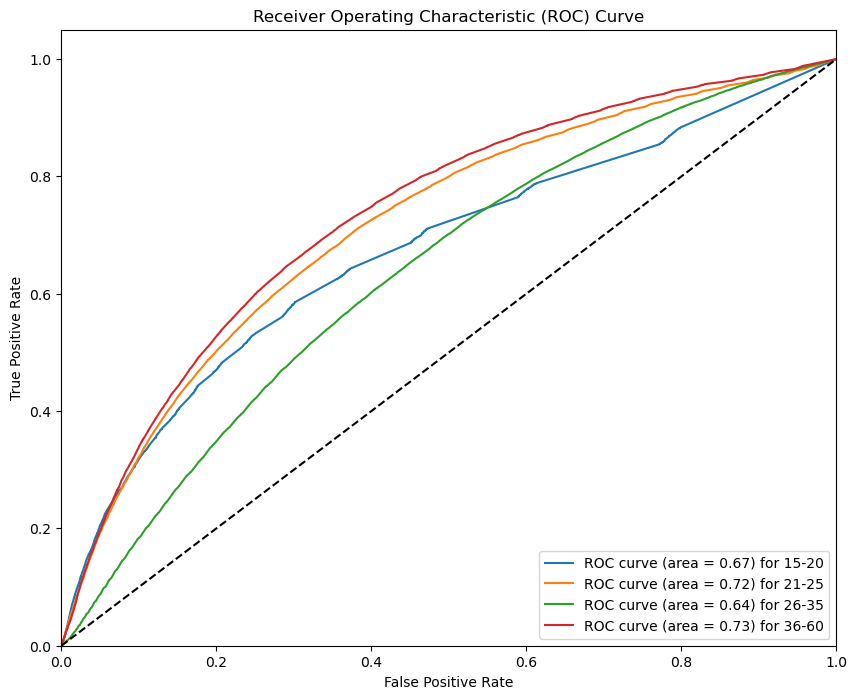

In [69]:
# Calculate the probabilities for each class
y_probs = clf.predict_proba(X_test)
roc_auc_score_value = roc_auc_score(y_test, y_proba, multi_class='ovr')  # 'ovr' for multi-class classification
print("AUC:", roc_auc_score_value)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(labels)):
    fpr[i], tpr[i], _ = roc_curve(y_test == labels[i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(labels)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve (area = {roc_auc[i]:.2f}) for {labels[i]}')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line representing random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


6- Age bins - 37% <br>
4- Age bins - 56%